### **Importing BHJet**

In [11]:
from pathlib import Path
import sys

ROOT = Path("/Users/ruby/Desktop/University/phd/bhjet_mod/modBHJet")
sys.path.insert(0, str(ROOT / "python"))

import numpy as np
import matplotlib.pyplot as plt

import bhjet
from bhjet import BLJet, BHJet
# print("Using bhjet from:", bhjet.__file__)

erg2eV = 6.242e+11 # 1erg in eV
eV2erg = 1/erg2eV

#### **Test that Help Functions Work** (peek into cpp code)

In [12]:
help(bhjet.BHJet.compton_threshold)

Help on property:

    (self) -> float



#### **Initial Setup of Code**

Need to start by setting up the dynamic profile of the jet that we want to reproduce. In this case it's the magnetic driven jet, which is called BLJet, which we'll name mag_jet_dyn. These parameters set up the jet properties, which will set up the jet profile (named jet). 

In [13]:
#with hand set parameters: 
mag_jet_dyn = BLJet(
    mass_bh=6e8,
    jet_power_eddington=1e-3,
    z_jet_launching=2,
    r_initial=5,
    z_end_of_acceleration=1e1,
    z_dissipation=120,
    z_max_calculation=1e6,
    sigma_final=1,
    gamma_final=3,
    electron_temperature_jet_base=1e2,
    fraction_nonthermal_electrons=0.1,
    index_injected_electrons=1.8,
    dlgz=0.1,
    verbosity_level=1,
    cutoff_type=0, 
)

In [14]:
bhjet = BHJet(
    theta_obs=17,
    distance=16e3,     # kpc
    redshift=0.00428,
    include_counterjet=True,
    compton_threshold=1e-5,
    profile_time=True,
    verbosity_level=1,
)
bhjet.init_jet_dynamics(mag_jet_dyn)

In [16]:
erg2eV = 6.242e+11 # 1erg in eV
eV2erg = 1/erg2eV

E_eV = np.logspace(-8, 19, 200)
bhjet.compute_full_jet(photon_energy_grid=E_eV * eV2erg) 
flux = bhjet.get_observed_photon_flux_total() #E dN/dE

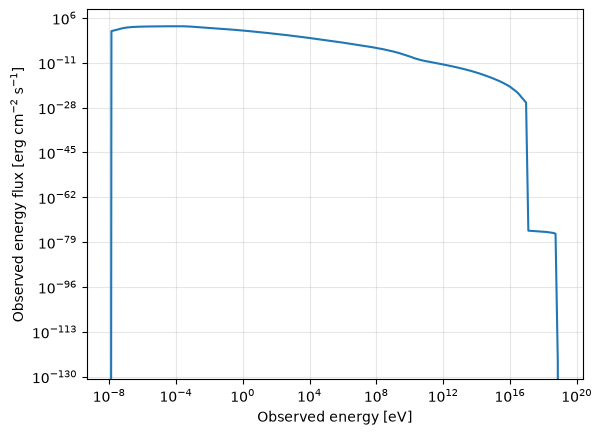

In [18]:
plt.loglog(E_eV, flux)
plt.xlabel("Observed energy [eV]")
plt.ylabel(r"Observed energy flux [erg cm$^{-2}$ s$^{-1}$]")
plt.grid(alpha=0.3)
# plt.ylim(1e-15, 1e-9)
plt.show()

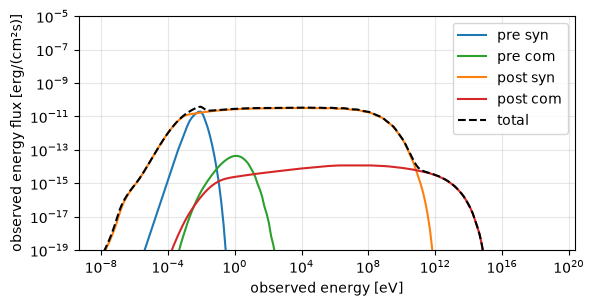

In [ ]:
fig, ax = plt.subplots()
# bhjet.set_target_black_body_luminosity("starlight", 1e45)

# ax.loglog(bb_starlight.get_observed_energy()*erg2eV, bb_starlight.get_observed_energy_flux(), label=bb_starlight.name, color="tab:purple")
# Ebb = bhjet.get_observed_photon_energy_grid_black_body("starlight")
# ax.loglog(Ebb*erg2eV, Ebb*bhjet.get_observed_photon_flux_black_body("starlight"), c="tab:purple", label="starlight")

ax.loglog(E_eV, E_eV*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(
    0, mag_jet_dyn.z_dissipation*mag_jet_dyn.r_g), c="tab:blue", label="pre syn")
ax.loglog(E_eV, E_eV*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_compton(
    0, mag_jet_dyn.z_dissipation*mag_jet_dyn.r_g), c="tab:green", label="pre com")
ax.loglog(E_eV, E_eV*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(
    mag_jet_dyn.z_dissipation*mag_jet_dyn.r_g, mag_jet_dyn.z_max_calculation*mag_jet_dyn.r_g), c="tab:orange", label="post syn")
ax.loglog(E_eV, E_eV*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_compton(
    mag_jet_dyn.z_dissipation*mag_jet_dyn.r_g, mag_jet_dyn.z_max_calculation*mag_jet_dyn.r_g), c="tab:red", label="post com")

ax.loglog(E_eV, E_eV*eV2erg*bhjet.get_observed_photon_flux_total(), c="k", label="total", ls="--")

ax.legend()
ax.set_xlabel(r"observed energy [eV]")
ax.set_ylabel(r"observed energy flux [erg/(cm²s)]")
ax.set_ylim(1e-19, 1e-5)
ax.set_aspect("equal")
ax.grid(alpha=0.3)

#### How to change the shape of the cutoff function: 

In [ ]:
energy = np.logspace(-8, 19, 200).tolist()

models = {}

for cutoff_type in [0, 1, 2]:
    dyn_i = BLJet(cutoff_type=cutoff_type)
    jet_i = BHJet()
    jet_i.init_jet_dynamics(dyn_i)
    jet_i.compute_full_jet(energy)
    models[cutoff_type] = np.asarray(jet_i.get_observed_photon_flux_total())

In [ ]:
plt.figure()

for cutoff_type, flux in models.items():
    plt.loglog(energy, flux, label=f"cutoff_type={cutoff_type}")

plt.xlabel("photon energy")
plt.ylabel("observed photon flux")
plt.ylim(1e-18, 1e18)
plt.legend()
plt.show()